In [3]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)
from sklearn.decomposition import PCA

In [4]:
customer_df = pd.read_csv("D:\clv\data\processed\customer_features.csv")

customer_df.head()

,customer_id,recency,frequency,monetary,avg_order_value,revenue_per_order,avg_revenue_per_product,total_products,unique_products,avg_basket_size,...,days_since_first_purchase,avg_purchase_interval,purchase_frequency_per_month,active_months,favorite_month,favorite_day,favorite_hour,country,return_rate,cancellation_rate
0,13085,157,8,2433.28,28.967619,304.160000,2.577627,944,50,44.952381,...,738,6.975904,0.413081,4,4,0,11,37,0.086957,0.086957
1,13078,2,57,29018.06,36.685284,509.088772,2.411740,12032,153,925.538462,...,738,0.901266,2.326531,25,9,6,13,37,0.063905,0.063905
2,15362,448,2,613.08,15.327000,306.540000,1.665978,368,38,184.000000,...,738,7.435897,0.206897,2,2,5,9,37,0.000000,0.000000
3,18102,0,145,580987.04,558.641385,4006.807172,3.198475,181645,382,181645.000000,...,738,0.674687,5.894309,23,10,5,11,37,0.009524,0.009524
4,12682,3,52,22950.22,23.205480,441.350385,2.181165,10522,327,1315.250000,...,738,0.717611,2.122449,25,9,5,13,13,0.003024,0.003024


In [5]:
features = [
    "recency",
    "frequency",
    "monetary",
    "avg_order_value",
    "avg_basket_size",
    "total_products",
    "unique_products",
    "product_diversity",
    "customer_lifetime_days",
    "avg_purchase_interval",
    "avg_revenue_per_product",
    "revenue_per_order"
    
]

X = customer_df[features].copy()

X.head()

,recency,frequency,monetary,avg_order_value,avg_basket_size,total_products,unique_products,product_diversity,customer_lifetime_days,avg_purchase_interval,avg_revenue_per_product,revenue_per_order
0,157,8,2433.28,28.967619,44.952381,944,50,0.052966,581,6.975904,2.577627,304.160000
1,2,57,29018.06,36.685284,925.538462,12032,153,0.012716,735,0.901266,2.411740,509.088772
2,448,2,613.08,15.327000,184.000000,368,38,0.103261,290,7.435897,1.665978,306.540000
3,0,145,580987.04,558.641385,181645.000000,181645,382,0.002103,738,0.674687,3.198475,4006.807172
4,3,52,22950.22,23.205480,1315.250000,10522,327,0.031078,735,0.717611,2.181165,441.350385


In [7]:
log_features = [
    "monetary",
    "avg_order_value",
    "avg_basket_size",
    "total_products",
    "unique_products",
    "customer_lifetime_days",
    "avg_revenue_per_product",
    "revenue_per_order"
]

X[log_features] = np.log1p(X[log_features])

X.head()

,recency,frequency,monetary,avg_order_value,avg_basket_size,total_products,unique_products,product_diversity,customer_lifetime_days,avg_purchase_interval,avg_revenue_per_product,revenue_per_order
0,157,8,7.797406,3.400117,3.827606,6.851185,3.931826,0.052966,6.366470,6.975904,1.274700,5.720836
1,2,57,10.275708,3.629270,6.831456,9.395408,5.036953,0.012716,6.601230,0.901266,1.227223,6.234585
2,448,2,6.420125,2.792820,5.220356,5.910797,3.663562,0.103261,5.673323,7.435897,0.980571,5.728605
3,0,145,13.272485,6.327296,12.109815,12.109815,5.948035,0.002103,6.605298,0.674687,1.434721,8.296000
4,3,52,10.041126,3.186579,7.182542,9.261319,5.793014,0.031078,6.601230,0.717611,1.157248,6.092102


In [8]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(5881, 12)


In [9]:
results = []

for k in range(2, 11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = model.fit_predict(X_scaled)

    results.append({
        "K": k,
        "Inertia": model.inertia_,
        "Silhouette": silhouette_score(X_scaled, labels),
        "Davies_Bouldin": davies_bouldin_score(X_scaled, labels),
        "Calinski_Harabasz": calinski_harabasz_score(X_scaled, labels)
    })

results_df = pd.DataFrame(results)

results_df

,K,Inertia,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,2,51589.534109,0.285394,1.368410,2163.210253
1,3,45944.657414,0.194001,1.567650,1575.373062
2,4,41744.720157,0.201937,1.346859,1352.818361
3,5,38507.322605,0.204917,1.333348,1223.235424
4,6,35122.982954,0.207265,1.272623,1185.912645
5,7,32242.311364,0.206772,1.179935,1163.840025
6,8,30130.064255,0.195097,1.229793,1126.145374
7,9,28305.771928,0.189587,1.288342,1096.013305
8,10,26700.289960,0.197127,1.286042,1071.862713


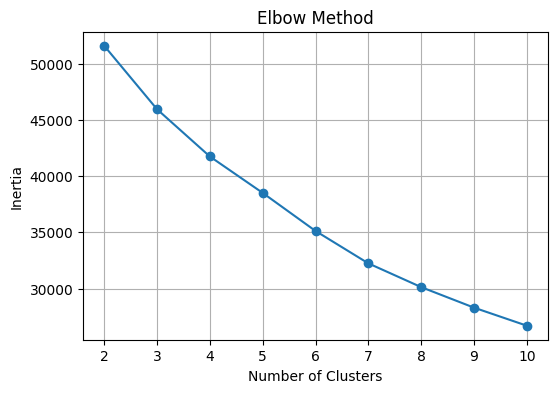

In [10]:
plt.figure(figsize=(6,4))

plt.plot(results_df["K"], results_df["Inertia"], marker="o")

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.grid(True)

plt.show()

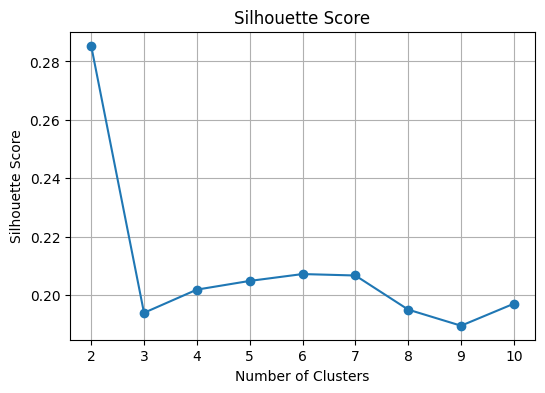

In [11]:
plt.figure(figsize=(6,4))

plt.plot(results_df["K"], results_df["Silhouette"], marker="o")

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score")

plt.grid(True)

plt.show()

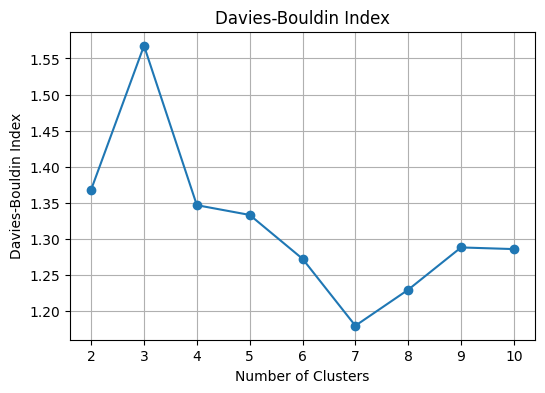

In [12]:
plt.figure(figsize=(6,4))

plt.plot(results_df["K"], results_df["Davies_Bouldin"], marker="o")

plt.xlabel("Number of Clusters")
plt.ylabel("Davies-Bouldin Index")
plt.title("Davies-Bouldin Index")

plt.grid(True)

plt.show()

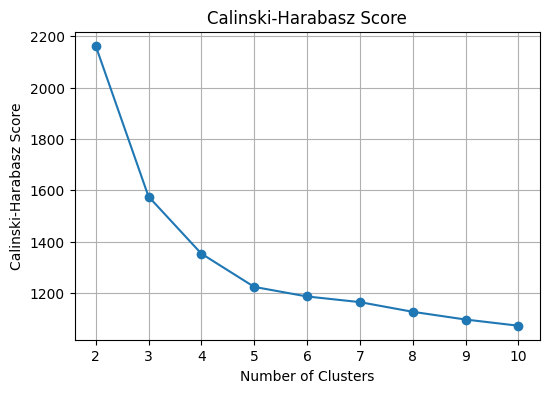

In [13]:
plt.figure(figsize=(6,4))

plt.plot(results_df["K"], results_df["Calinski_Harabasz"], marker="o")

plt.xlabel("Number of Clusters")
plt.ylabel("Calinski-Harabasz Score")
plt.title("Calinski-Harabasz Score")

plt.grid(True)

plt.show()

In [14]:
best_k = 6

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=20
)

customer_df["cluster"] = kmeans.fit_predict(X_scaled)

customer_df.head()

,customer_id,recency,frequency,monetary,avg_order_value,revenue_per_order,avg_revenue_per_product,total_products,unique_products,avg_basket_size,...,avg_purchase_interval,purchase_frequency_per_month,active_months,favorite_month,favorite_day,favorite_hour,country,return_rate,cancellation_rate,cluster
0,13085,157,8,2433.28,28.967619,304.160000,2.577627,944,50,44.952381,...,6.975904,0.413081,4,4,0,11,37,0.086957,0.086957,0
1,13078,2,57,29018.06,36.685284,509.088772,2.411740,12032,153,925.538462,...,0.901266,2.326531,25,9,6,13,37,0.063905,0.063905,1
2,15362,448,2,613.08,15.327000,306.540000,1.665978,368,38,184.000000,...,7.435897,0.206897,2,2,5,9,37,0.000000,0.000000,0
3,18102,0,145,580987.04,558.641385,4006.807172,3.198475,181645,382,181645.000000,...,0.674687,5.894309,23,10,5,11,37,0.009524,0.009524,1
4,12682,3,52,22950.22,23.205480,441.350385,2.181165,10522,327,1315.250000,...,0.717611,2.122449,25,9,5,13,13,0.003024,0.003024,1


cluster
0    2453
1    1294
2    1566
3      38
4     483
5      47
Name: count, dtype: int64


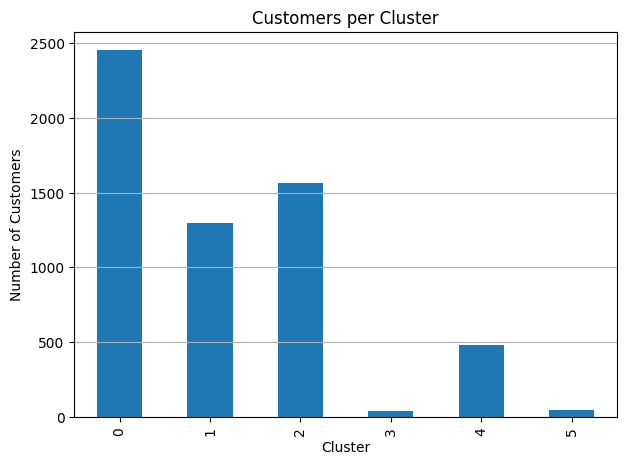

In [15]:
cluster_counts = customer_df["cluster"].value_counts().sort_index()

print(cluster_counts)

plt.figure(figsize=(7,5))

cluster_counts.plot(kind="bar")

plt.title("Customers per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

plt.grid(axis="y")

plt.show()

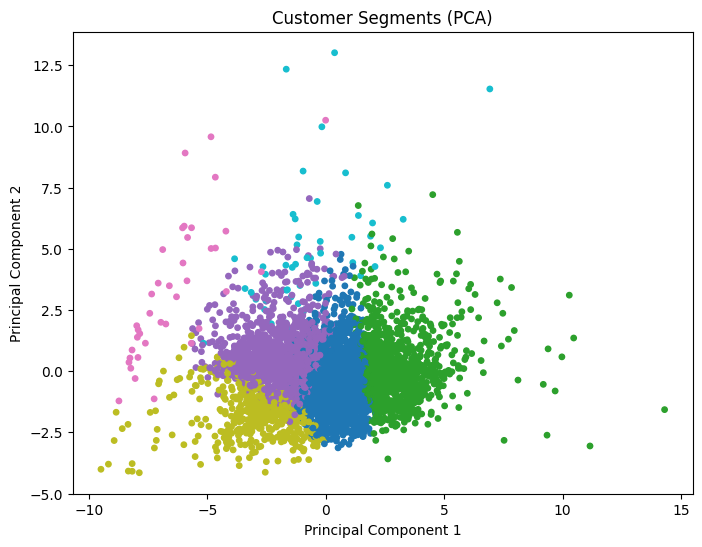

In [16]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=customer_df["cluster"],
    cmap="tab10",
    s=15
)

plt.title("Customer Segments (PCA)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

In [17]:
cluster_profile = (
    customer_df
    .groupby("cluster")[features]
    .mean()
    .round(2)
)

cluster_profile

,recency,frequency,monetary,avg_order_value,avg_basket_size,total_products,unique_products,product_diversity,customer_lifetime_days,avg_purchase_interval,avg_revenue_per_product,revenue_per_order
cluster,,,,,,,,,,,,
0,143.07,4.53,1227.23,20.01,289.97,706.16,73.01,0.12,330.87,6.38,1.92,313.43
1,58.32,17.56,10353.31,49.81,2767.74,6404.11,197.63,0.06,545.41,2.93,1.82,643.37
2,353.74,1.33,341.93,35.76,85.06,195.20,15.94,0.10,19.99,1.94,2.19,283.11
3,458.21,1.39,2300.72,1165.19,4.23,5.71,1.29,0.73,5.92,2.88,788.88,1182.38
4,360.18,1.75,255.19,6.96,52.37,138.88,45.50,0.43,74.41,1.51,2.92,159.98
5,151.89,3.40,4703.84,1417.21,2390.28,2906.60,3.09,0.04,425.26,145.92,3.04,2066.54


In [18]:
cluster_summary = (
    customer_df
    .groupby("cluster")
    .agg(
        Customers=("customer_id", "count"),
        Avg_Recency=("recency", "mean"),
        Avg_Frequency=("frequency", "mean"),
        Avg_Monetary=("monetary", "mean"),
        Avg_Order_Value=("avg_order_value", "mean"),
        Avg_Basket_Size=("avg_basket_size", "mean")
    )
    .round(2)
)

cluster_summary

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Avg_Order_Value,Avg_Basket_Size
cluster,,,,,,
0,2453,143.07,4.53,1227.23,20.01,289.97
1,1294,58.32,17.56,10353.31,49.81,2767.74
2,1566,353.74,1.33,341.93,35.76,85.06
3,38,458.21,1.39,2300.72,1165.19,4.23
4,483,360.18,1.75,255.19,6.96,52.37
5,47,151.89,3.40,4703.84,1417.21,2390.28


In [19]:
segment_map = {
    0: "One-Time Buyers",
    1: "Regular Customers",
    2: "Low-Value Customers",
    3: "Premium Niche Customers",
    4: "High-Value Loyal Customers",
    5: "VIP Customers"
}

customer_df["segment"] = customer_df["cluster"].map(segment_map)

customer_df[["customer_id", "cluster", "segment"]].head()

,customer_id,cluster,segment
0,13085,0,One-Time Buyers
1,13078,1,Regular Customers
2,15362,0,One-Time Buyers
3,18102,1,Regular Customers
4,12682,1,Regular Customers


In [20]:
segment_distribution = (
    customer_df["segment"]
    .value_counts()
    .reset_index()
)

segment_distribution.columns = ["Segment", "Customers"]

segment_distribution

,Segment,Customers
0,One-Time Buyers,2453
1,Low-Value Customers,1566
2,Regular Customers,1294
3,High-Value Loyal Customers,483
4,VIP Customers,47
5,Premium Niche Customers,38


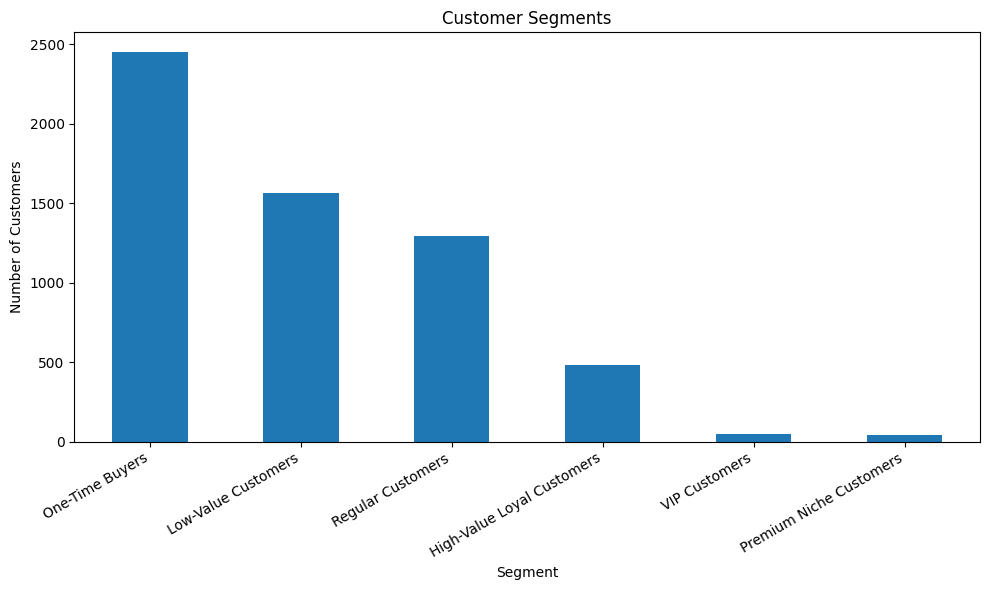

In [21]:
plt.figure(figsize=(10,6))

customer_df["segment"].value_counts().plot(kind="bar")

plt.title("Customer Segments")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

VIP Customers (21 customers)

Highest monetary value (~145k)
Highest purchase frequency
Longest customer lifetime
Strategy: Offer exclusive rewards, concierge support, and early access to products.

High-Value Loyal Customers (1649 customers)

High purchase frequency and spending
Strong long-term engagement
Strategy: Loyalty programs, personalized recommendations, and cross-selling.

Regular Customers (2083 customers)

Moderate purchase frequency and spending
Largest customer segment
Strategy: Increase basket size with promotions and bundles.

One-Time Buyers (1118 customers)

Purchased only once
Limited engagement
Strategy: Welcome emails, first-repeat discounts, and remarketing campaigns.

Low-Value Customers (946 customers)

Low spending and low purchase frequency
Strategy: Targeted promotions and low-cost retention campaigns.

Premium Customers (61 customers)

Very high average order value but infrequent purchases
Strategy: High-touch service and personalized offers to encourage repeat purchases.

In [22]:
customer_df.to_csv("customer_segments.csv", index=False)

print("customer_segments.csv saved successfully!")

customer_segments.csv saved successfully!


In [23]:
cluster_profile.to_csv("cluster_profile.csv")

print("cluster_profile.csv saved successfully!")

cluster_profile.csv saved successfully!


In [25]:
import joblib

joblib.dump(
    kmeans,
    "models/customer_segmentation.pkl"
)

print("Segmentation model saved successfully.")


joblib.dump(
    scaler,
    "models/customer_segmentation_scaler.pkl"
)

print("Customer Segmentation scaler saved.")

Segmentation model saved successfully.
Customer Segmentation scaler saved.
